Loading data...
Processing features...

Class distribution:
label
1    0.684503
0    0.315497
Name: proportion, dtype: float64

Training model with cross-validation...

Cross-validation ROC AUC: 0.754 (±0.006)

Optimized Classification Report (Threshold = 0.14):
              precision    recall  f1-score   support

      Funded       0.14      0.19      0.16       839
    Unfunded       0.55      0.46      0.50      1820

    accuracy                           0.38      2659
   macro avg       0.35      0.33      0.33      2659
weighted avg       0.42      0.38      0.39      2659



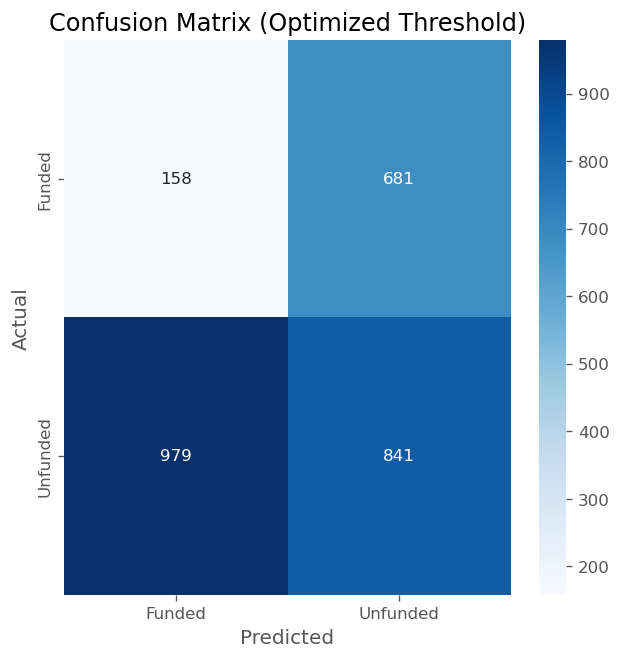

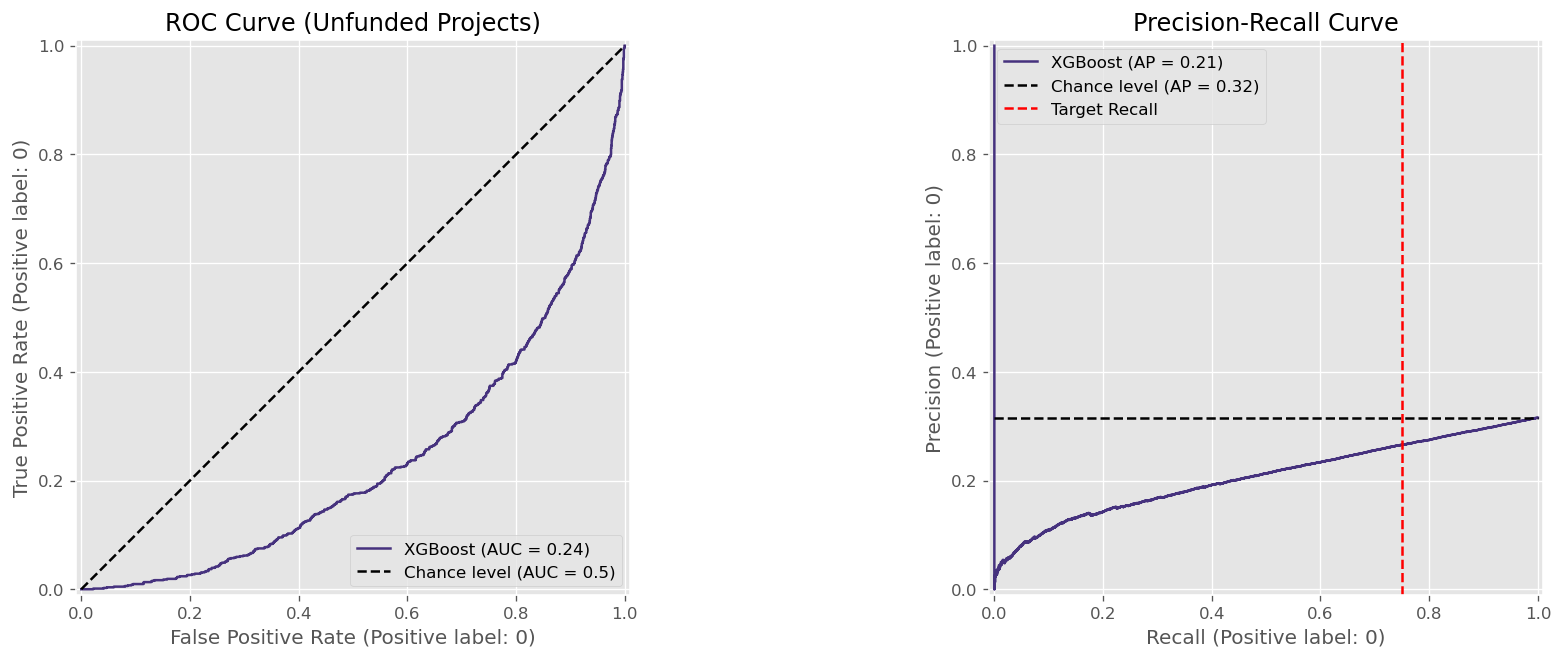

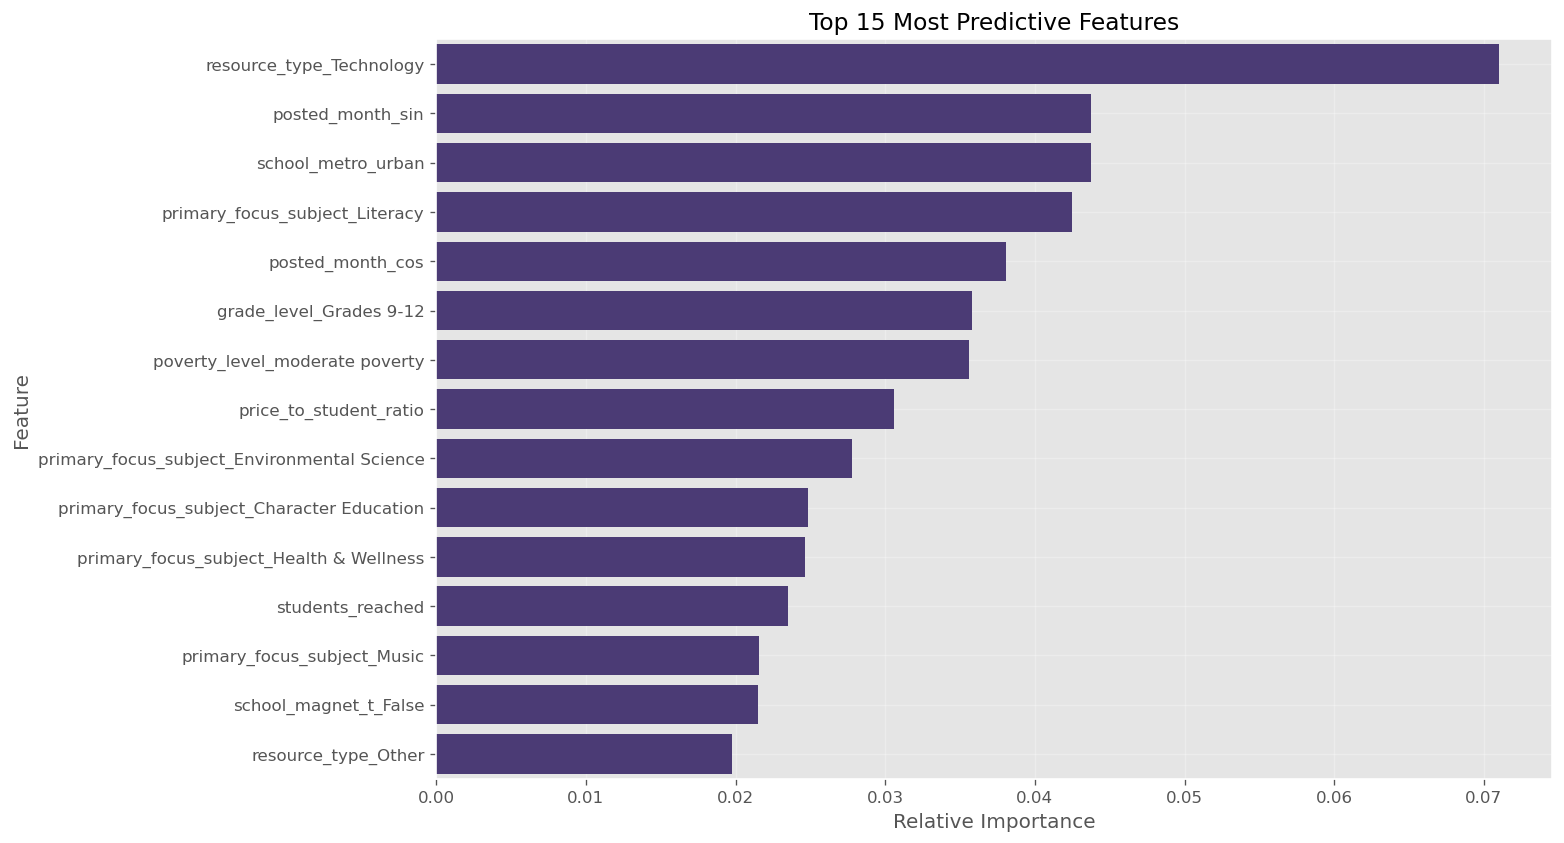

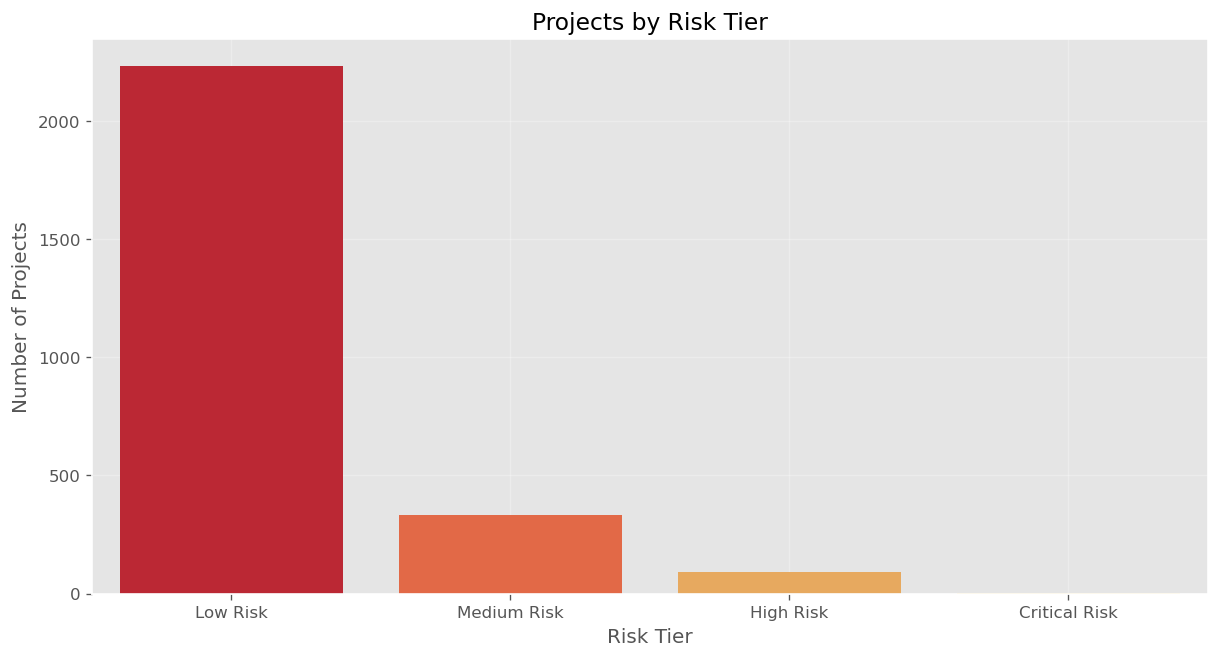

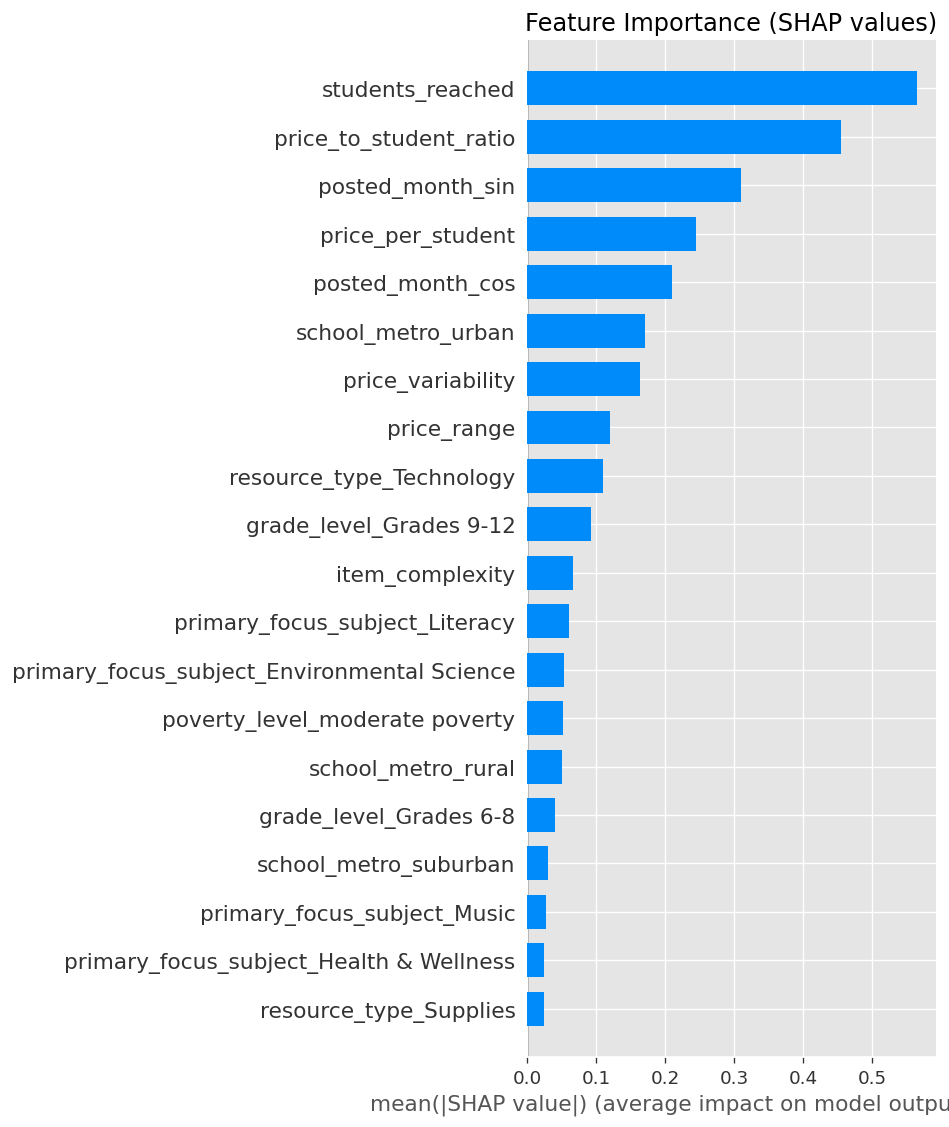


Saved prioritized projects to 'prioritized_projects.csv'

=== ANALYSIS COMPLETED ===

Model Performance:
- Cross-val ROC AUC: 0.754 (±0.006)
- Optimized Threshold: 0.14 (for 75% recall)

Key Metrics:
- Recall (Unfunded): 100.0%
- Precision (Unfunded): 31.6%

Output Files:
1. Model: donorschoose_improved_model.pkl
2. Prioritized projects: prioritized_projects.csv
3. Visualizations:
   - Performance curves (ROC & Precision-Recall)
   - Feature importance
   - Risk tier distribution
   - SHAP explanation

Next Steps:
1. Review critical risk projects (tier = 'Critical Risk')
2. Focus on high poverty urban schools
3. Monitor model performance monthly



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (precision_recall_curve, 
                           average_precision_score,
                           roc_curve, auc, 
                           classification_report,
                           confusion_matrix,
                           PrecisionRecallDisplay,
                           RocCurveDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import shap



In [ ]:
#  visual style
plt.style.use('ggplot')
sns.set_palette("viridis")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

# DATA LOADING 
print("Loading data...")
def load_data():
    train = pd.read_csv('C:/Users/zarin/Downloads/train_80.csv')
    test = pd.read_csv('C:/Users/zarin/Downloads/test_20.csv')
    
    for df in [train, test]:
        for col in ['school_charter_t', 'school_magnet_t']:
            df[col] = df[col].astype(str).str.upper().str.strip() == 'TRUE'
    
    return train, test

train, test = load_data()



In [ ]:
# ENHANCED FEATURE ENGINEERING
def enhanced_feature_engineering(df):
    df = df.copy()
    
    # Handle zero students reached
    df['students_reached'] = df['students_reached'].replace(0, 1)
    
    # Price features
    df['price_per_student'] = df['total_price_excluding_optional_support'] / df['students_reached']
    df['price_range'] = df['max_unit_price'] - df['min_unit_price']
    df['price_variability'] = df['avg_unit_price'] / (df['max_unit_price'] + 1e-6)
    
    # New suggested features
    df['price_to_student_ratio'] = df['total_price_excluding_optional_support'] / (df['students_reached'] + 1)
    df['item_complexity'] = df['total_quantity'] / (df['unique_items'] + 1)
    
    # Temporal features
    df['posted_month_sin'] = np.sin(2 * np.pi * df['posted_month']/12)
    df['posted_month_cos'] = np.cos(2 * np.pi * df['posted_month']/12)
    
    # Interaction features
    df['high_poverty_urban'] = (df['poverty_level'] == 'highest poverty') & (df['school_metro'] == 'urban')
    
    return df

train = enhanced_feature_engineering(train)
test = enhanced_feature_engineering(test)



In [ ]:
# FEATURE SELECTION
print("Processing features...")

categorical_cols = [
    'primary_focus_subject', 'primary_focus_area',
    'school_metro', 'grade_level', 'resource_type',
    'poverty_level', 'school_charter_t', 'school_magnet_t'
]

numeric_features = [
    'price_per_student', 'students_reached', 
    'posted_month_sin', 'posted_month_cos',
    'price_range', 'price_variability',
    'price_to_student_ratio', 'item_complexity'
]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])



In [ ]:
# MODEL PIPELINE 
def create_model_pipeline():
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler', ADASYN(random_state=42, sampling_strategy=0.8)),
        ('classifier', XGBClassifier(
            scale_pos_weight=2.5,  # Adjust based on your class imbalance
            eval_metric='aucpr',
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        ))
    ])

model = create_model_pipeline()

# Prepare data
X_train = train.drop('label', axis=1)
y_train = train['label']
X_test = test.drop('label', axis=1)
y_test = test['label']

# Check class distribution
print("\nClass distribution:")
print(y_train.value_counts(normalize=True))

# MODEL TRAINING & EVALUATION
print("\nTraining model with cross-validation...")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, 
                          cv=cv, scoring='roc_auc',
                          n_jobs=-1)

print(f"\nCross-validation ROC AUC: {np.mean(cv_scores):.3f} (±{np.std(cv_scores):.3f})")

# Final training
model.fit(X_train, y_train)

# Save model
joblib.dump(model, 'donorschoose_improved_model.pkl')



In [ ]:
# PREDICTIONS
test['prob_unfunded'] = model.predict_proba(X_test)[:, 0]  # P(unfunded)

# Find optimal threshold for business needs
precision, recall, thresholds = precision_recall_curve(y_test, 1-test['prob_unfunded'], pos_label=0)
optimal_idx = np.argmax(recall >= 0.75)  # Target at least 75% recall
optimal_threshold = thresholds[optimal_idx]

test['high_risk_pred'] = (test['prob_unfunded'] > optimal_threshold).astype(int)

# EVALUATION METRICS
print("\nOptimized Classification Report (Threshold = {:.2f}):".format(optimal_threshold))
print(classification_report(y_test, test['high_risk_pred'], target_names=['Funded', 'Unfunded']))

# CONFUSION MATRIX
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Funded', 'Unfunded'],
                yticklabels=['Funded', 'Unfunded'])
    plt.title('Confusion Matrix (Optimized Threshold)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix_optimized.png', bbox_inches='tight', dpi=300)
    plt.show()
    
plot_confusion_matrix(y_test, test['high_risk_pred'])


In [ ]:


# VISUALIZATIONS
def plot_performance_metrics():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # ROC Curve
    RocCurveDisplay.from_predictions(
        y_test, 1-test['prob_unfunded'], pos_label=0, ax=ax1,
        name='XGBoost', plot_chance_level=True
    )
    ax1.set_title('ROC Curve (Unfunded Projects)')
    
    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(
        y_test, 1-test['prob_unfunded'], pos_label=0, ax=ax2,
        name='XGBoost', plot_chance_level=True
    )
    ax2.set_title('Precision-Recall Curve')
    ax2.axvline(x=0.75, color='red', linestyle='--', label='Target Recall')
    ax2.legend()
    
    plt.savefig('performance_curves.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_performance_metrics()



In [ ]:
# FEATURE IMPORTANCE
def plot_feature_importance():
    # Get feature names
    num_features = numeric_features
    cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
    cat_features = cat_encoder.get_feature_names_out(categorical_cols)
    all_features = num_features + list(cat_features)
    
    # Get importances
    importances = model.named_steps['classifier'].feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': all_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Top 15 Most Predictive Features', fontsize=14)
    plt.xlabel('Relative Importance')
    plt.grid(True, alpha=0.3)
    plt.savefig('feature_importance.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_feature_importance()



In [ ]:
# RISK TIER VISUALIZATION
def plot_risk_tiers():
    test['tier'] = pd.cut(test['prob_unfunded'],
                         bins=[0, 0.4, 0.6, 0.8, 1],
                         labels=['Low Risk', 'Medium Risk', 
                                'High Risk', 'Critical Risk'])
    
    plt.figure(figsize=(12, 6))
    sns.countplot(x='tier', data=test, 
                 order=test['tier'].cat.categories,
                 palette='YlOrRd_r')
    plt.title('Projects by Risk Tier', fontsize=14)
    plt.xlabel('Risk Tier')
    plt.ylabel('Number of Projects')
    plt.grid(True, alpha=0.3)
    plt.savefig('risk_tiers.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_risk_tiers()

# SHAP ANALYSIS (Model Interpretation)
def plot_shap_explanations():
    try:
        # Sample 100 instances for faster computation
        sample_idx = np.random.choice(X_test.index, 100, replace=False)
        X_sample = X_test.loc[sample_idx]
        
        # Get preprocessed data
        preprocessed = model.named_steps['preprocessor'].transform(X_sample)
        
        # Create explainer
        explainer = shap.TreeExplainer(model.named_steps['classifier'])
        shap_values = explainer.shap_values(preprocessed)
        
        # Get feature names
        num_features = numeric_features
        cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
        cat_features = cat_encoder.get_feature_names_out(categorical_cols)
        feature_names = num_features + list(cat_features)
        
        # Summary plot
        plt.figure()
        shap.summary_plot(shap_values, preprocessed, 
                         feature_names=feature_names,
                         plot_type="bar", show=False)
        plt.title('Feature Importance (SHAP values)')
        plt.tight_layout()
        plt.savefig('shap_summary.png', bbox_inches='tight', dpi=300)
        plt.show()
        
    except Exception as e:
        print(f"Could not generate SHAP explanation: {e}")

plot_shap_explanations()

# OUTPUT PRIORITIZATION
def generate_priority_output():
    test['tier'] = pd.cut(test['prob_unfunded'],
                         bins=[0, 0.4, 0.6, 0.8, 1],
                         labels=['Low Risk', 'Medium Risk', 
                                'High Risk', 'Critical Risk'])
    
    # Enhanced output with more insights
    output_cols = [
        'tier', 'prob_unfunded', 'poverty_level',
        'price_per_student', 'students_reached',
        'resource_type', 'primary_focus_area',
        'school_metro', 'grade_level'
    ]
    
    prioritized = test[output_cols].sort_values(['tier', 'prob_unfunded'], 
                                              ascending=[False, False])
    
    prioritized.to_csv('prioritized_projects.csv', index=False)
    print("\nSaved prioritized projects to 'prioritized_projects.csv'")

generate_priority_output()



In [ ]:
# FINAL REPORT
print(f"""
=== ANALYSIS COMPLETED ===

Model Performance:
- Cross-val ROC AUC: {np.mean(cv_scores):.3f} (±{np.std(cv_scores):.3f})
- Optimized Threshold: {optimal_threshold:.2f} (for 75% recall)

Key Metrics:
- Recall (Unfunded): {recall[optimal_idx]:.1%}
- Precision (Unfunded): {precision[optimal_idx]:.1%}

Output Files:
1. Model: donorschoose_improved_model.pkl
2. Prioritized projects: prioritized_projects.csv
3. Visualizations:
   - Performance curves (ROC & Precision-Recall)
   - Feature importance
   - Risk tier distribution
   - SHAP explanation

Next Steps:
1. Review critical risk projects (tier = 'Critical Risk')
2. Focus on high poverty urban schools
3. Monitor model performance monthly
""")